#Task 1 — Data Import & Setup


##1.Import CSV using Pandas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
#Mounting the Drive to colab notebook
from google.colab import drive
drive.mount('/content/drive')

#Read a CSV file from Drive
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/social_media_engagement_5000.csv")
df_copy=df.copy
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


##2.Check/convert data types


In [ ]:
print("Dataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-n

In [ ]:
print("Data types of columns:")
df.dtypes

Data types of columns:


,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


##3.Convert date columns to datetime

In [ ]:
print(f"posted_at Before cleaning :\n{df['posted_at'].unique()}")
df['posted_at']=pd.to_datetime(df['posted_at'],format='mixed',errors='coerce',dayfirst=True)
print(f"posted_at after cleaning :\n{df['posted_at'].unique()}")


posted_at Before cleaning :
['17-12-2022' '02-06-2023' '07-05-2023' '12-02-2023' '23-05-2023'
 '16-09-2023' '15-04-2022' '20-12-2023' '06-07-2023' '16-11-2022'
 '15-02-2022' '29-08-2022' '27-09-2022' '29-10-2023' '20-09-2023'
 '06-02-2022' '24-07-2022' '01-05-2023' '20-04-2022' '14-11-2022'
 '15-08-2023' '17-03-2022' '02-09-2023' '13-05-2023' '24-04-2023'
 '24-01-2023' '11-08-2023' '16-08-2023' '30-12-2022' '05-11-2022'
 '04-03-2022' '24-09-2022' '02-02-2022' '09-02-2022' '17-11-2023'
 '17-09-2022' '23-10-2023' '13-08-2022' '18-01-2023' '01-10-2023'
 '05-01-2022' '22-03-2023' '15-10-2022' '27-02-2022' '13-03-2022'
 '11-11-2023' '25-06-2023' '23-03-2022' '10-09-2023' '04-10-2022'
 '06-06-2023' '28-07-2023' '16-05-2022' '24-04-2022' '06-06-2022'
 '31-01-2023' '17-08-2022' '04-09-2023' '12-09-2022' '28-06-2022'
 '02-01-2023' '31-01-2022' '18-04-2022' '09-10-2022' '13-09-2023'
 '25-01-2023' '13-06-2023' '08-02-2023' '19-06-2022' '24-06-2022'
 '15-03-2022' '30-03-2023' '24-05-2023' '28-08-2

#Task 2 — Data Cleaning


##1.Cleaning Missing Data
■ Detect missing values (isnull(), isna())
■ Handle using: dropna(), fillna(), median/mode, forward/backward-fill


In [ ]:
print("Missing values in each column:")
df.isnull().sum()



Missing values in each column:


,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
print(f"age Before cleaning :\n{df['age'].unique()}")
print(f"gender Before cleaning :\n{df['gender'].unique()}")
print(f"likes Before cleaning :\n{df['likes'].unique()}")
print(f"comments Before cleaning :\n{df['comments'].unique()}")
print(f"shares Before cleaning :\n{df['shares'].unique()}")
print(f"sentiment Before cleaning :\n{df['sentiment'].unique()}")


age Before cleaning :
[43. 33. 32. 51. 34. 16. 25. 57. 54. 62. 61. 64. 29. 48. 45. 13. 27. 36.
 20. 39. 35. 58. 38. 59. 49. nan 37. 28. 14. 30. 42. 44. 41. 55. 60. 52.
 31. 21. 22. 56. 47. 23. 46. 24. 26. 63. 18. 50. 53. 40. 15. 17. 19.]
gender Before cleaning :
['Female' 'Male' 'Other' nan]
likes Before cleaning :
[ 7011. 11750.  4862. ... 19664. 14677. 16924.]
comments Before cleaning :
[ 354. 2606.  344. ... 1451. 1443. 1755.]
shares Before cleaning :
[1157. 1807.  955. ...  177. 1155. 1530.]
sentiment Before cleaning :
['negative' 'positive' 'neutral' nan]


In [ ]:
#Age
df['age']=df['age'].fillna(df['age'].median())
df['age']=df['age'].astype('int')
#Gender
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
#sentiment
df['sentiment']=df['sentiment'].fillna(df['sentiment'].mode()[0])

In [ ]:
#likes
#comments
#shares
for col in ['likes', 'comments', 'shares']:
    df[col] = df[col].fillna(df.groupby(['gender', 'age'])[col].transform('mean'))

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

print(f"age After cleaning :\n{df['age'].unique()}")
print(f"gender After cleaning :\n{df['gender'].unique()}")
print(f"likes After cleaning :\n{df['likes'].unique()}")
print(f"comments After cleaning :\n{df['comments'].unique()}")
print(f"shares After cleaning :\n{df['shares'].unique()}")
print(f"sentiment After cleaning :\n{df['sentiment'].unique()}")



Missing values in each column:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64
age After cleaning :
[43 33 32 51 34 16 25 57 54 62 61 64 29 48 45 13 27 36 20 39 35 58 38 59
 49 37 28 14 30 42 44 41 55 60 52 31 21 22 56 47 23 46 24 26 63 18 50 53
 40 15 17 19]
gender After cleaning :
['Female' 'Male' 'Other']
likes After cleaning :
[ 7011. 11750.  4862. ... 19664. 14677. 16924.]
comments After cleaning :
[ 354. 2606.  344. ... 1451. 1443. 1755.]
shares After cleaning :
[1157. 1807.  955. ...  177. 1155. 1530.]
sentiment After cleaning :
['negative' 'positive' 'neutral']


##2.Duplicate Handling- Identify & remove duplicates


In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

df=df.drop_duplicates()

Number of duplicate rows: 0


##3.Data Formatting
■ Fix incorrect data types
■ Standardize categories (e.g., gender labels)
■ Correct unrealistic values in likes, comments, shares


In [ ]:
#data type conversion
df['user_id']=df['user_id'].astype('object')
df['post_id']=df['post_id'].astype('object')
df.dtypes

,0
user_id,object
age,int64
gender,object
country,object
post_id,object
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df['sentiment'] = df['sentiment'].str.title()
df['gender']=df['gender'].str.title()
df['device_type']=df['device_type'].str.title()
df['post_type']=df['post_type'].str.title()
df['post_category']=df['post_category'].str.title()
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,Reel,Food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32,Female,UK,109864,Text,Food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51,Other,France,848877,Text,Fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,Image,Fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372


In [ ]:
print(df['country'].unique())
print(df['post_type'].unique())
print(df['post_category'].unique())
print(df['is_verified'].unique())
print(df['device_type'].unique())
print(df['sentiment'].unique())

['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
['Image' 'Reel' 'Text' 'Video']
['Fitness' 'Food' 'Tech' 'Travel' 'Fashion' 'Lifestyle' 'Education'
 'Music']
[False  True]
['Mobile' 'Tablet' 'Desktop']
['Negative' 'Positive' 'Neutral']


In [ ]:
#check for negative values
print((df['likes'] < 0).sum())
print((df['comments'] < 0).sum())
print((df['shares'] < 0).sum())

0
0
0


In [ ]:
#Removing outliers in likes,comments,share
print(df.shape)
for col in ['likes','comments','shares']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(df[col].clip(lower, upper))
    df[col] = df[col].clip(lower, upper)
print(df.shape)

(5000, 19)
0        7011.0
1       11750.0
2        4862.0
3        5350.0
4       12682.0
         ...   
4995    16210.0
4996    16924.0
4997    13487.0
4998    16894.0
4999    14830.0
Name: likes, Length: 5000, dtype: float64
0        354.000000
1       2606.000000
2        344.000000
3       1083.000000
4       2735.000000
           ...     
4995    2013.000000
4996    2734.000000
4997    1474.172414
4998    1289.000000
4999     503.000000
Name: comments, Length: 5000, dtype: float64
0       1157.0
1       1807.0
2        955.0
3       1049.0
4       1300.0
         ...  
4995    1837.0
4996    1583.0
4997     167.0
4998    1713.0
4999    1798.0
Name: shares, Length: 5000, dtype: float64
(5000, 19)


##4.Feature Cleaning
■ Extract hashtag count
■ Clean sentiment labels

In [ ]:
df['hashtag_count'] = df['hashtags'].str.findall(r'#\w+').str.len()
print(df['hashtag_count'].unique())
print(df['sentiment'].unique())

[3 1 2]
['Negative' 'Positive' 'Neutral']


#Task 3 — Data Exploration using Pandas
Perform the following:


##1.View dataset structure using head(), tail(), shape, and columns.


In [ ]:
print(f"Head :\n{df.head()}")
print("--"*50)
print(f"Tail :\n{df.tail()}")
print("--"*50)
print(f"Shape :\n{df.shape}")

Head :
  user_id  age  gender country post_id post_type post_category    likes  \
0   25795   43  Female  Brazil  496713     Image       Fitness   7011.0   
1   10860   33    Male  Brazil  157326      Reel          Food  11750.0   
2   86820   32  Female      UK  109864      Text          Food   4862.0   
3   64886   51   Other  France  848877      Text       Fitness   5350.0   
4   16265   34   Other      UK  449706     Image       Fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      Mobile  Negative  

##2.Check data types and info with info() and dtypes.


In [ ]:
print("Dataset Info:")
df.info()
print("--"*50)
print(f"Data Type of the columns:\n{df.dtypes}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   object        
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   object        
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verifie

##3.Generate summary statistics using describe().


In [ ]:
print("Statistical summary:")
df.describe()

Statistical summary:


,age,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,38.440400,10108.556918,1501.987694,1002.487483,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,13.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,26.000000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,38.000000,10093.923077,1496.234375,1009.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,51.000000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,64.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,14.687151,5705.383103,856.887336,571.156447,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


##4.Analyze categorical distributions using value_counts(), unique(), and nunique().


In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
not_need=['user_id','post_id']
cate_cols=[col for col in categorical_cols if col not in not_need]
for col in cate_cols:

    print(f"\nAnalysis of {col}")
    print("-"*50)

    print("Unique Values:")
    print(df[col].unique())

    print("\nNumber of Unique Values:")
    print(df[col].nunique())

    print("\nFrequency Distribution:")
    print(df[col].value_counts())

    print("\nPercentage Distribution:")
    print(round(df[col].value_counts(normalize=True)*100,2))


Analysis of gender
--------------------------------------------------
Unique Values:
['Female' 'Male' 'Other']

Number of Unique Values:
3

Frequency Distribution:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Percentage Distribution:
gender
Male      36.98
Other     31.62
Female    31.40
Name: proportion, dtype: float64

Analysis of country
--------------------------------------------------
Unique Values:
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

Number of Unique Values:
10

Frequency Distribution:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Percentage Distribution:
country
India        10.70
Canada       10.26
Brazil       10.08
UAE          10.06
USA          10.02
France        9.92
UK            9.86
Australia     9.86
Germany       9.80
Japan   

##5.Create a correlation matrix for numeric fields.


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

                       age     likes  comments    shares  watch_time_sec  \
age               1.000000 -0.037276 -0.006732  0.013848        0.005542   
likes            -0.037276  1.000000 -0.019595  0.004615        0.008523   
comments         -0.006732 -0.019595  1.000000  0.005683       -0.016477   
shares            0.013848  0.004615  0.005683  1.000000        0.015022   
watch_time_sec    0.005542  0.008523 -0.016477  0.015022        1.000000   
impression_count  0.013322  0.007929 -0.009022 -0.005181       -0.004335   
follower_count   -0.024894 -0.022949 -0.010701 -0.010177        0.002761   
engagement_rate   0.008039  0.093409 -0.000384  0.021761       -0.001148   
hashtag_count     0.007173 -0.002033 -0.015595  0.014351       -0.023301   

                  impression_count  follower_count  engagement_rate  \
age                       0.013322       -0.024894         0.008039   
likes                     0.007929       -0.022949         0.093409   
comments                 -

##6.Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

###Average Likes by Post Type

In [ ]:
avg_likes_post_type =df.groupby('post_type')['likes'].mean().sort_values(ascending=False)
print(avg_likes_post_type )

post_type
Video    10187.871505
Image    10105.635515
Text     10102.809977
Reel     10041.244028
Name: likes, dtype: float64


###Average Comments by Post Type

In [ ]:
avg_comments_post_type =df.groupby('post_type')['comments'].mean().sort_values(ascending=False)
print(avg_comments_post_type )

post_type
Image    1525.038973
Reel     1505.058934
Text     1500.426333
Video    1476.892629
Name: comments, dtype: float64


###Average Shares by Post Type

In [ ]:
avg_shares_post_type =df.groupby('post_type')['shares'].mean().sort_values(ascending=False)
print(avg_shares_post_type )

post_type
Image    1018.873851
Text     1014.177135
Video     995.479834
Reel      981.908333
Name: shares, dtype: float64


###Average Impressions by Country

In [ ]:
avg_impression_ctry =df.groupby('country')['impression_count'].mean().sort_values(ascending=False)
print(avg_impression_ctry )

country
India        52462.386916
France       51727.673387
USA          51263.872255
UK           51119.393509
Japan        49616.135593
Brazil       49193.174603
UAE          48928.413519
Canada       48703.150097
Germany      48605.406122
Australia    48346.383367
Name: impression_count, dtype: float64


#Task 4 — Data Wrangling  
● Use merge, concat, or join if combining DataFrames.
● Create new fields such as engagement_score, log-transformed metrics
(optional), and hashtag count.
● Perform groupby summaries by post_type, country, and sentiment.

##Engagement Score

In [ ]:
df['engagement_score']=df['likes']+df['shares']+df['comments']
post_type_engagement = df.groupby('post_type')['engagement_score'].mean().sort_values(ascending=False)
print(post_type_engagement)

post_type
Video    12660.243969
Image    12649.548339
Text     12617.413446
Reel     12528.211296
Name: engagement_score, dtype: float64


##Log Features

In [ ]:
# Log Features
df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])

##GroupBy - Post Type

In [ ]:
post_type_summary = df.groupby('post_type')[['likes','comments','shares','engagement_score']].mean().round(2)
print(post_type_summary)

              likes  comments   shares  engagement_score
post_type                                               
Image      10105.64   1525.04  1018.87          12649.55
Reel       10041.24   1505.06   981.91          12528.21
Text       10102.81   1500.43  1014.18          12617.41
Video      10187.87   1476.89   995.48          12660.24


##GroupBy - Country

In [ ]:
# GroupBy - Country
country_summary = df.groupby('country')[['impression_count','engagement_score','engagement_rate']].mean().round(2)
print(country_summary)

           impression_count  engagement_score  engagement_rate
country                                                       
Australia          48346.38          12810.91             1.32
Brazil             49193.17          12374.00             1.54
Canada             48703.15          12598.23             0.92
France             51727.67          12908.26             1.15
Germany            48605.41          12652.34             0.76
India              52462.39          12506.32             0.66
Japan              49616.14          12574.56             0.77
UAE                48928.41          12749.31             1.11
UK                 51119.39          12379.98             0.85
USA                51263.87          12585.92             0.58


##GroupBy - Sentiment

In [ ]:
sentiment_summary = df.groupby('sentiment')[['likes','comments','shares','engagement_score']].mean().round(2)
print(sentiment_summary)

              likes  comments   shares  engagement_score
sentiment                                               
Negative   10209.07   1516.81  1006.46          12732.34
Neutral     9920.96   1528.57   996.51          12446.04
Positive   10184.15   1480.17  1004.60          12668.92


#Task 5 — Statistical Analysis  
Compute descriptive stats for “likes, comments, shares, watch_time,
engagement_rate, followers” columns:
● Mean, median, mode
● Standard deviation, variance
● Percentiles
● (Optional) Skewness and kurtosis

In [ ]:

cols=['likes','comments', 'shares', 'watch_time_sec','engagement_rate', 'follower_count']

stats_summary = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Mode': [df[c].mode()[0] for c in cols],
    'Std Dev': df[cols].std(),
    'Variance': df[cols].var(),
    '25%': df[cols].quantile(0.25),
    '50%': df[cols].quantile(0.50),
    '75%': df[cols].quantile(0.75),
    'Skewness': df[cols].skew(),
    'Kurtosis': df[cols].kurt()
}).round(2)

print(stats_summary)

                      Mean     Median       Mode    Std Dev      Variance  \
likes             10108.56   10093.92   10575.36    5705.38  3.255140e+07   
comments           1501.99    1496.23    2934.00     856.89  7.342559e+05   
shares             1002.49    1009.00     138.00     571.16  3.262197e+05   
watch_time_sec     4014.50    4034.50     916.00    2308.10  5.327309e+06   
engagement_rate       0.96       0.25       0.01       5.32  2.828000e+01   
follower_count   393698.22  388982.00  497502.00  230927.88  5.332769e+10   

                       25%        50%        75%  Skewness  Kurtosis  
likes              5235.00   10093.92   14959.00     -0.01     -1.15  
comments            792.00    1496.23    2235.25      0.00     -1.15  
shares              511.00    1009.00    1483.00     -0.01     -1.15  
watch_time_sec     2017.75    4034.50    6020.25     -0.02     -1.20  
engagement_rate       0.15       0.25       0.50     18.78    482.99  
follower_count   194480.00  388982

###Insights
| Metric              | Key Statistics                                                        | Insights                                                                                                                                                                                            |
| ------------------- | --------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Likes**           | Mean = 10,108.56<br>Median = 10,093.92<br>Skewness = -0.01            | The mean and median are nearly identical, indicating a symmetric distribution. User engagement through likes is evenly distributed across posts, with no significant influence from extreme values. |
| **Comments**        | Mean = 1,501.99<br>Median = 1,496.23<br>Skewness = 0.00               | Comments show a balanced distribution with consistent user interaction levels. The similarity between mean and median suggests minimal outlier impact.                                              |
| **Shares**          | Mean = 1,002.49<br>Median = 1,009.00<br>Skewness = -0.01              | Sharing behavior is relatively stable across the dataset. The distribution is approximately normal, indicating consistent content-sharing patterns.                                                 |
| **Watch Time**      | Mean = 4,014.50 sec<br>Median = 4,034.50 sec<br>Skewness = -0.02      | Watch time is evenly distributed, suggesting that most content retains viewer attention for similar durations.                                                                                      |
| **Engagement Rate** | Mean = 0.96<br>Median = 0.25<br>Skewness = 18.78<br>Kurtosis = 482.99 | Engagement rate is highly right-skewed. A small number of posts achieve exceptionally high engagement, indicating the presence of viral content and significant outliers.                           |
| **Follower Count**  | Mean = 393,698<br>Median = 388,982<br>Skewness = 0.04                 | Follower counts are fairly balanced across users. The close mean and median values indicate a well-distributed audience base.                                                                       |


# Task 6 — Data Visualization (Min. 8 Plots Required)


##1.Matplotlib


###Scatter: likes vs impressions


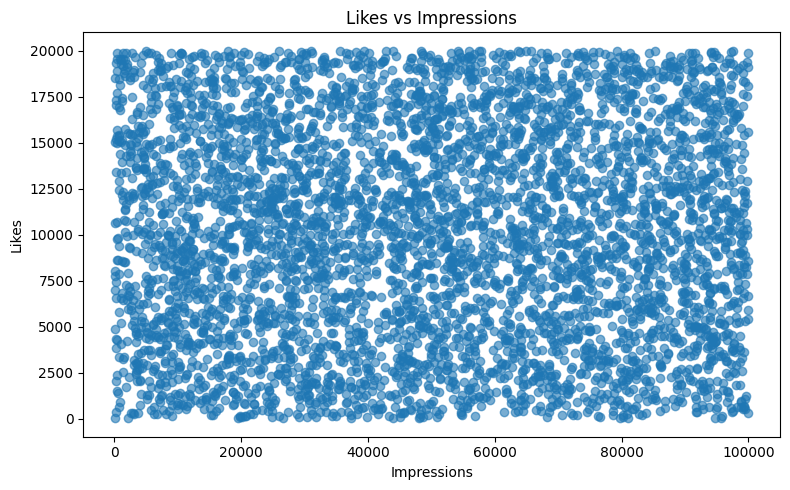

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['impression_count'],
    df['likes'],
    alpha=0.6
)

plt.title('Likes vs Impressions')
plt.xlabel('Impressions')
plt.ylabel('Likes')

plt.tight_layout()
plt.show()

####Interpretation:
1. The scatter plot shows a broad distribution of likes across all impression levels.
2. Posts with both low and high impressions can receive either low or high numbers of likes.
3. The points are widely dispersed, indicating a weak visual relationship between impressions and likes.
4. No major clusters or distinct patterns are observed.
####Insight:
The number of impressions alone does not appear to be a strong predictor of likes. While impressions increase content visibility, other factors such as content quality, relevance, sentiment, posting time, and audience characteristics likely play a significant role in determining user engagement.

###Line: daily engagement trend


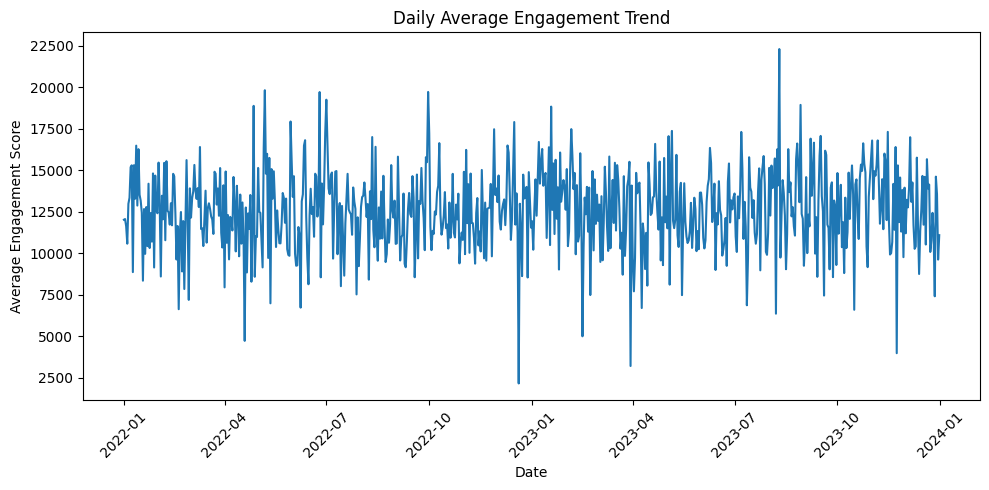

In [ ]:
daily_engagement=df.groupby('posted_at')['engagement_score'].mean()
plt.figure(figsize=(10,5))

plt.plot(daily_engagement.index,daily_engagement.values)
plt.title('Daily Average Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Average Engagement Score')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

| Aspect           | Interpretation                                                                                                                                                   |
| ---------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Trend            | No significant long-term increasing or decreasing trend is observed.                                                                                             |
| Stability        | Average engagement remains relatively stable throughout the period.                                                                                              |
| Peaks            | Several engagement spikes indicate highly successful content or campaigns.                                                                                       |
| Dips             | Temporary drops suggest periods of lower audience interaction.                                                                                                   |
| Business Insight | Consistent engagement levels indicate a stable audience base, while peak periods can be analyzed further to identify characteristics of high-performing content. |


###Bar: posts by category


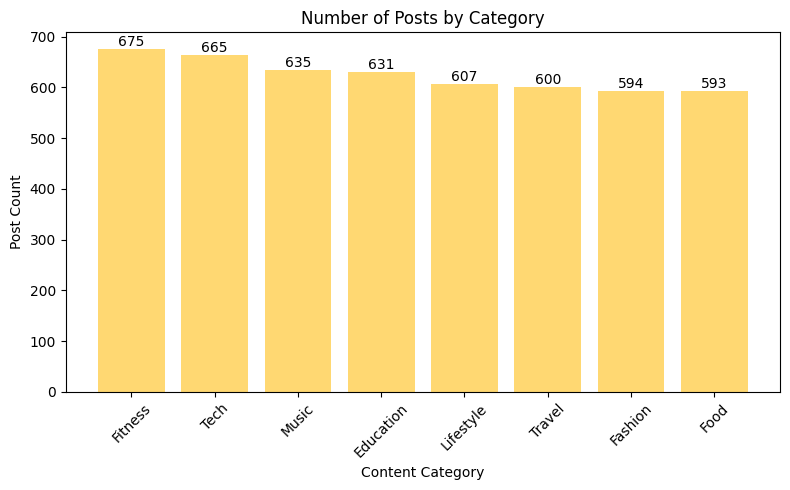

In [ ]:
category_counts=df['post_category'].value_counts()
plt.figure(figsize=(8,5))

bars = plt.bar(category_counts.index,category_counts.values,color='#FFD872')

plt.title('Number of Posts by Category')
plt.xlabel('Content Category')
plt.ylabel('Post Count')

plt.bar_label(bars)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

| Aspect            | Interpretation                                                                                                                         |
| ----------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| Highest Category  | Fitness has the highest number of posts (675).                                                                                         |
| Lowest Category   | Food has the lowest number of posts (593).                                                                                             |
| Distribution      | Categories are relatively evenly distributed.                                                                                          |
| Content Diversity | The platform supports a diverse range of content topics.                                                                               |
| Business Insight  | A balanced category distribution reduces content concentration risk and allows engagement analysis across multiple audience interests. |


###Pie: gender distribution


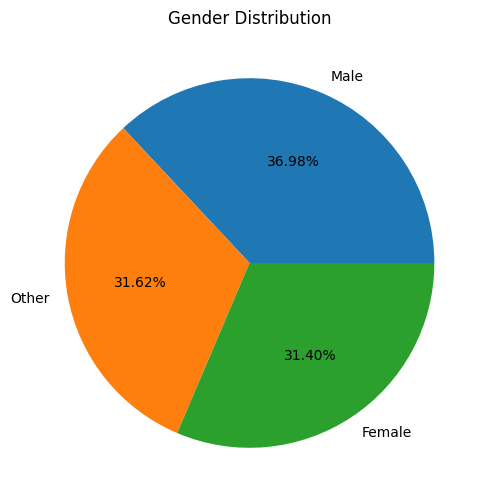

In [ ]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.2f%%')

plt.title('Gender Distribution')

plt.show()

| Aspect                | Interpretation                                                                                                                     |
| --------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| Largest Segment       | Male users constitute 36.98% of the dataset.                                                                                       |
| Female Representation | Female users account for 31.40% of users.                                                                                          |
| Other Category        | Other users represent 31.62% of the dataset.                                                                                       |
| Distribution          | Gender distribution is fairly balanced across all categories.                                                                      |
| Diversity             | The dataset demonstrates strong demographic diversity.                                                                             |
| Business Insight      | Since no single gender dominates the dataset, engagement patterns can be analyzed across genders with minimal representation bias. |


###Histogram: age


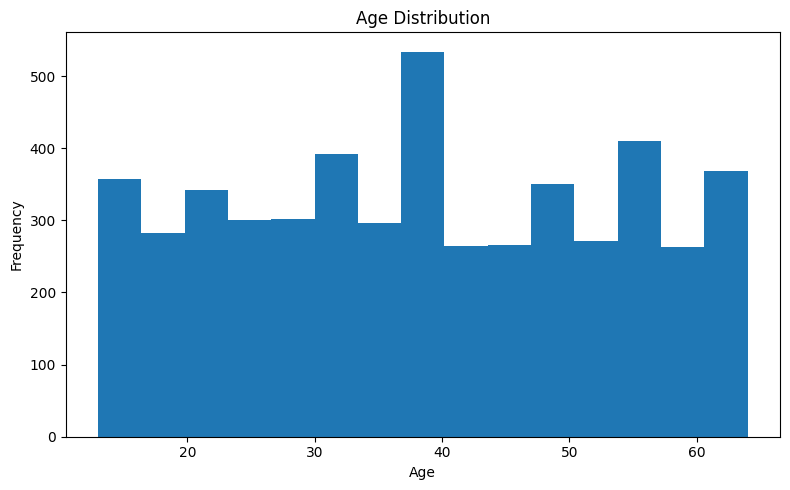

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['age'],bins=15)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

| Aspect           | Interpretation                                                                                                                                      |
| ---------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| Age Range        | Users range approximately from 13 to 65 years old.                                                                                                  |
| Distribution     | Ages are fairly evenly distributed across the dataset.                                                                                              |
| Peak Range       | Slightly higher concentration is observed around ages 35–40.                                                                                        |
| Diversity        | The dataset contains users from multiple age groups and generations.                                                                                |
| Business Insight | The platform appeals to a broad audience, allowing content strategies to target multiple age segments rather than focusing on a single demographic. |


###Box: engagement rate


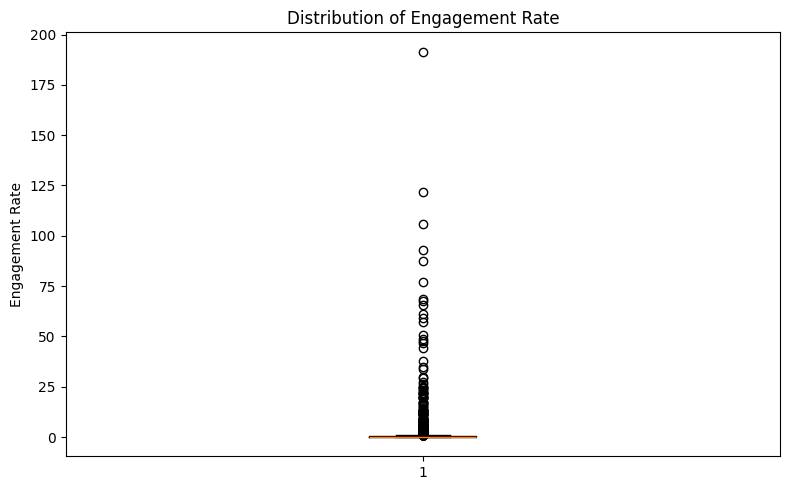

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df['engagement_rate'])

plt.title('Distribution of Engagement Rate')
plt.ylabel('Engagement Rate')

plt.tight_layout()
plt.show()

| Aspect           | Interpretation                                                                                                                                                            |
| ---------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Median           | The median engagement rate is very low, indicating that most posts receive moderate engagement.                                                                           |
| Spread           | Most observations are concentrated within a narrow engagement range.                                                                                                      |
| Outliers         | Numerous extreme outliers are present above the upper whisker.                                                                                                            |
| Distribution     | The engagement rate distribution is highly positively skewed.                                                                                                             |
| Business Insight | A small percentage of posts generate exceptionally high engagement, highlighting the importance of identifying and replicating characteristics of top-performing content. |


##2.Seaborn


###Count plot: post type


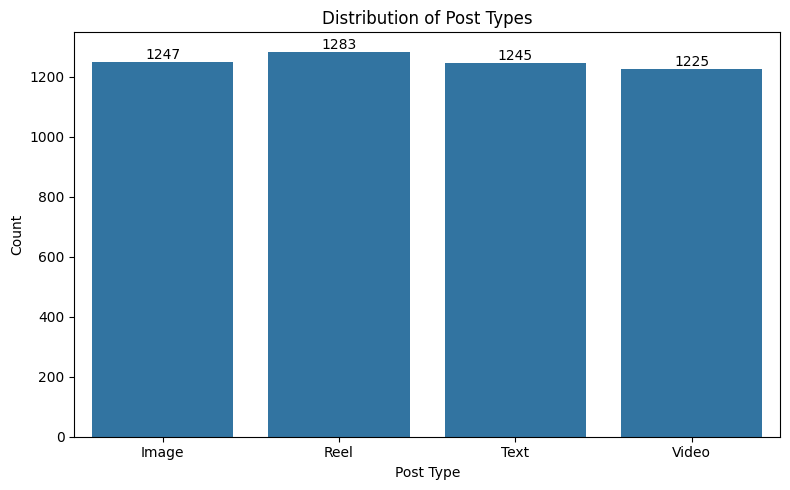

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,x='post_type')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

| Aspect                 | Interpretation                                                                                                                           |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| Most Common Post Type  | Reel (1,283 posts)                                                                                                                       |
| Least Common Post Type | Video (1,225 posts)                                                                                                                      |
| Distribution           | All post types are nearly equally represented.                                                                                           |
| Content Strategy       | The platform maintains a balanced mix of content formats.                                                                                |
| Business Insight       | Since post type frequencies are similar, differences in engagement are more likely due to content quality rather than posting frequency. |


###Bar plot: avg likes by category


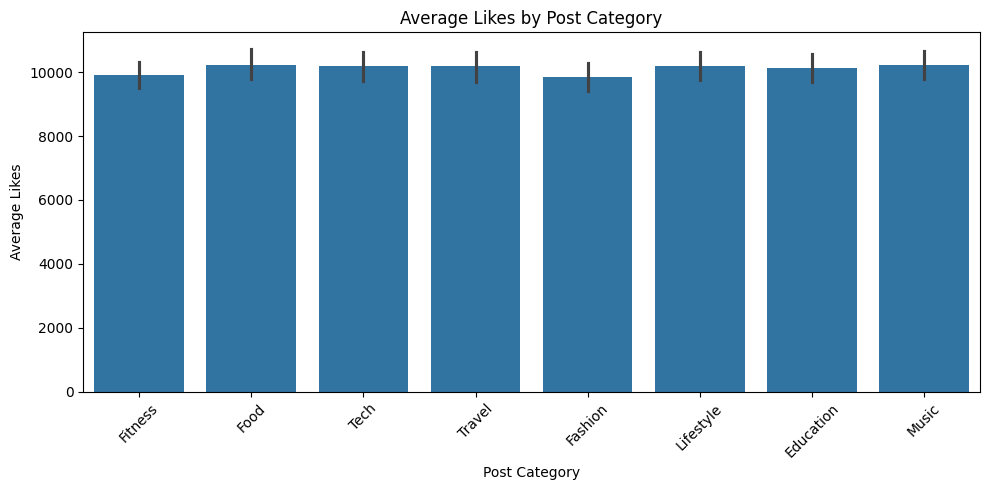

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(data=df,x='post_category',y='likes',estimator='mean')

plt.title('Average Likes by Post Category')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

| Aspect                | Interpretation                                                                                                               |
| --------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| Highest Average Likes | Food category receives the highest average likes.                                                                            |
| Lowest Average Likes  | Fashion category receives the lowest average likes.                                                                          |
| Distribution          | Average likes are very similar across all categories.                                                                        |
| Variability           | Error bars indicate moderate variation within categories.                                                                    |
| Business Insight      | Category selection alone does not significantly impact likes; content quality and audience relevance may play a larger role. |


###Violin: followers vs sentiment


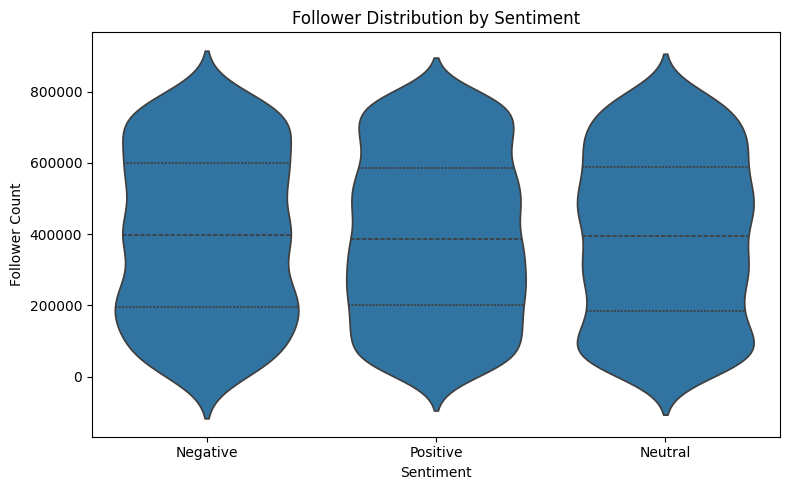

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(data=df,x='sentiment',y='follower_count',inner='quart')

plt.title('Follower Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')

plt.tight_layout()
plt.show()

| Aspect           | Interpretation                                                                |
| ---------------- | ----------------------------------------------------------------------------- |
| Distribution     | All sentiment categories show similar follower distributions.                 |
| Range            | Follower counts span a broad range across all sentiments.                     |
| Median           | Median follower counts are approximately the same for all groups.             |
| Variation        | Similar variability exists among Positive, Negative, and Neutral posts.       |
| Business Insight | Sentiment does not appear to influence the follower size of content creators. |


###Pair plot: numeric features


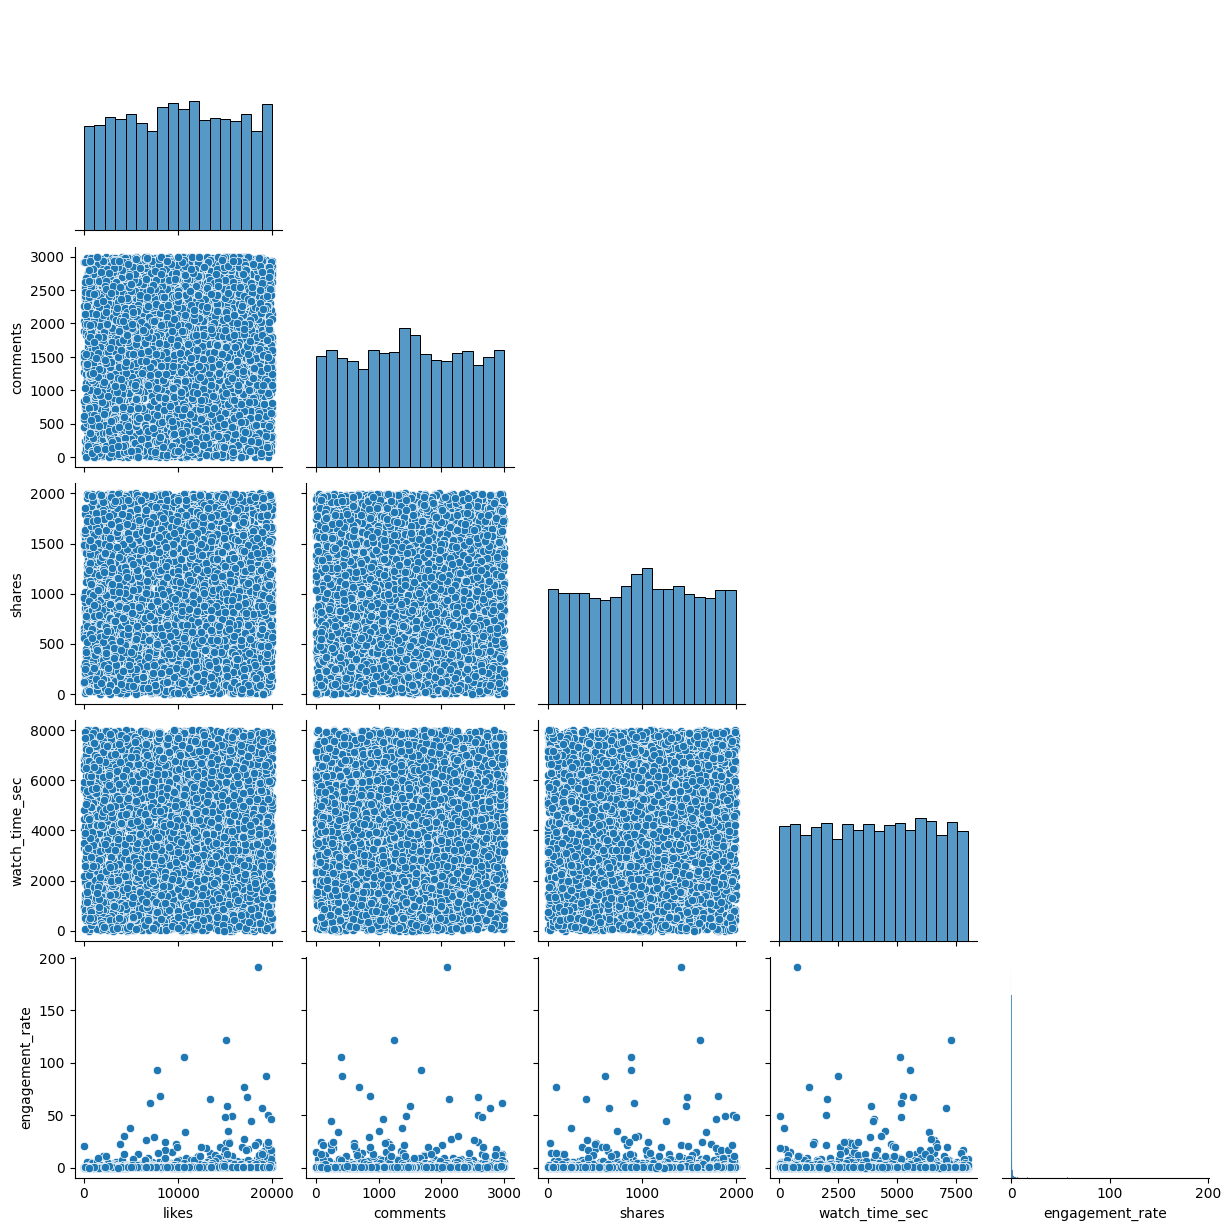

In [ ]:
pair_cols = ['likes','comments','shares','watch_time_sec','engagement_rate']

sns.pairplot(df[pair_cols],corner=True)

plt.show()

| Aspect                  | Interpretation                                                                                   |
| ----------------------- | ------------------------------------------------------------------------------------------------ |
| Likes Distribution      | Broadly distributed across the dataset.                                                          |
| Comments Distribution   | Fairly uniform with no dominant range.                                                           |
| Shares Distribution     | Spread across the full range of values.                                                          |
| Watch Time Distribution | Evenly distributed with moderate variability.                                                    |
| Engagement Rate         | Highly skewed with numerous outliers.                                                            |
| Correlation             | No strong visual relationships between variables.                                                |
| Business Insight        | User engagement appears to be driven by multiple factors rather than a single engagement metric. |


###Heatmap: correlation matrix


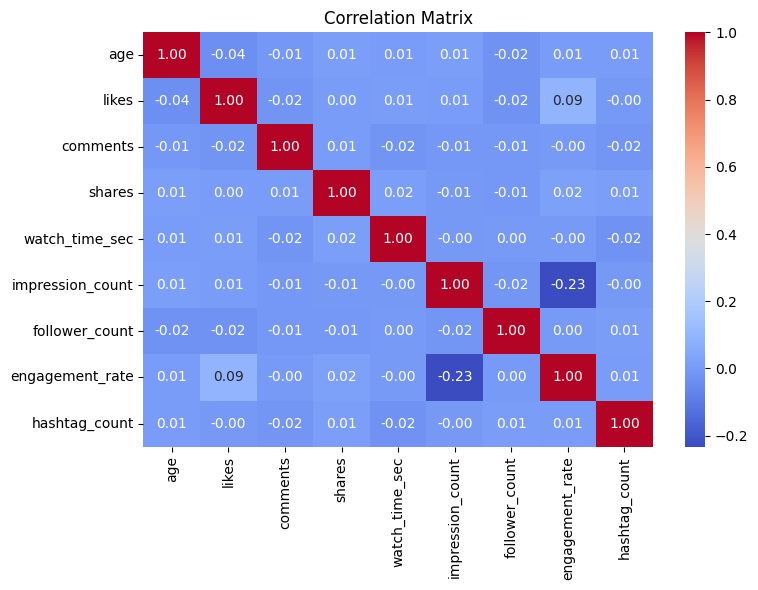

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

| Finding                             | Correlation        | Interpretation                    |
| ----------------------------------- | ------------------ | --------------------------------- |
| Impression Count vs Engagement Rate | -0.23              | Weak negative relationship        |
| Likes vs Engagement Rate            | 0.09               | Very weak positive relationship   |
| Age vs Likes                        | -0.04              | No meaningful relationship        |
| Follower Count vs Engagement Rate   | 0.00               | No relationship                   |
| Hashtag Count vs Engagement Metrics | ≈0.00              | No significant impact             |
| Overall Matrix                      | Most values near 0 | Variables are largely independent |


###Swarm plot: engagement vs device


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

70.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

71.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

70.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

73.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

75.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



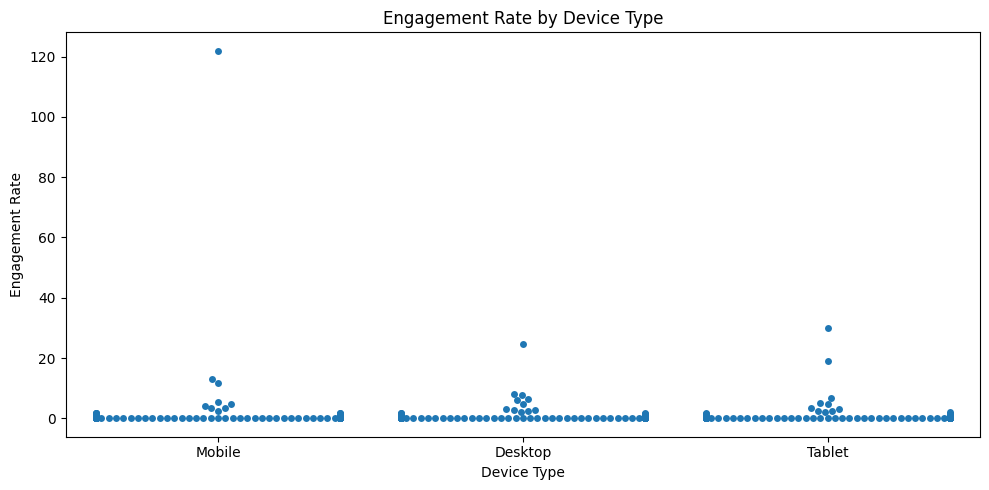

In [ ]:
plt.figure(figsize=(10,5))

sns.swarmplot(data=df.sample(500, random_state=42),x='device_type',y='engagement_rate')

plt.title('Engagement Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')

plt.tight_layout()
plt.show()

| Aspect           | Interpretation                                                                     |
| ---------------- | ---------------------------------------------------------------------------------- |
| Distribution     | Most engagement rates are concentrated at low values across all devices.           |
| Mobile           | Contains the highest engagement-rate outlier (~122).                               |
| Desktop          | Shows moderate variability with a few high-engagement posts.                       |
| Tablet           | Includes some high-engagement outliers but fewer extreme values.                   |
| Overall Pattern  | Device types exhibit broadly similar engagement distributions.                     |
| Business Insight | Device type does not appear to strongly influence engagement rate in this dataset. |


##3.Plotly (Interactive)


###1.Interactive Line Chart – Daily Engagement Trend

In [ ]:
daily_engagement = df.groupby('posted_at')['engagement_score'].mean().reset_index()
fig = px.line(daily_engagement,x='posted_at',y='engagement_score',title='Daily Engagement Trend',markers=True)
fig.show()

| Aspect           | Interpretation                                                                                                   |
| ---------------- | ---------------------------------------------------------------------------------------------------------------- |
| Trend            | No significant long-term increase or decrease is observed.                                                       |
| Stability        | Engagement remains relatively stable throughout the period.                                                      |
| Peaks            | Several days exhibit exceptionally high engagement (>20,000).                                                    |
| Dips             | A few days experience unusually low engagement (<5,000).                                                         |
| Overall Pattern  | Daily engagement fluctuates but remains centered around a consistent average level.                              |
| Business Insight | The platform maintains a stable audience, while certain posts or campaigns generate temporary engagement surges. |


###2.Interactive Bar Chart – Average Likes by Category

In [ ]:
avg_likes = df.groupby('post_category')['likes'].mean().reset_index()
fig = px.bar(avg_likes,x='post_category',y='likes',title='Average Likes by Post Category',text_auto='.0f')
fig.show()

####Key Findings
1. Highest Performing Category: Food
2. Lowest Performing Category: Fashion
3. Overall Variation: Very small
4. Audience Preference: Fairly balanced across categories
####Business Insight:
Since average likes are nearly identical across all content categories, creators should not rely solely on category selection to increase engagement. Other factors such as content quality, visual design, posting time, sentiment, hashtags, and audience targeting are likely to have a greater impact on performance.

###3.Interactive Scatter Plot – Likes vs Impressions

In [ ]:
fig = px.scatter(df,x='impression_count',y='likes',color='sentiment',hover_data=['post_type','country'],
                 title='Likes vs Impressions')
fig.show()

| Aspect           | Interpretation                                               |
| ---------------- | ------------------------------------------------------------ |
| Relationship     | Weak relationship between impressions and likes.             |
| Sentiment Impact | Positive, Neutral, and Negative posts show similar patterns. |
| Clustering       | No distinct clusters are visible.                            |
| Trend            | No clear positive or negative correlation.                   |
| Business Insight | High reach does not automatically guarantee high engagement. |


###4.Interactive Bubble Chart

In [ ]:
fig = px.scatter(df,x='impression_count',y='likes',size='engagement_score',
    color='post_category',hover_name='post_type',title='Engagement Bubble Chart')
fig.show()

| Aspect                | Interpretation                                                     |
| --------------------- | ------------------------------------------------------------------ |
| Impressions vs Likes  | Weak relationship observed.                                        |
| Bubble Size           | Larger bubbles indicate higher engagement scores.                  |
| High Engagement Posts | Mostly associated with higher likes.                               |
| Category Performance  | High-performing posts exist across all categories.                 |
| Business Insight      | Content quality influences engagement more than impressions alone. |


#Task7:
Final Insights should include the following analysis:
1. Content Performance
--> Which post types have the highest engagement?
--> Best-performing content category?
--> Which countries have the highest average engagement rate?  
2. User Trends
--> How age affects engagement
--> Performance difference for verified accounts
3. Behavioral Insights
--> Best time of day for impressions
--> Device type impact on watch time
4. Sentiment Analysis
--> Which sentiment performs best
--> Behavior of negative/neutral sentiment posts

##Highest Engagement Post Types

In [ ]:
high_engagement_posts=df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)
print(high_engagement_posts)

post_type
Video    1.122365
Text     1.064549
Image    0.895646
Reel     0.783047
Name: engagement_rate, dtype: float64


##Countries with Highest Average Engagement Rate

In [ ]:
country_engagement = df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)
print(country_engagement)

country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


##Best Month for Impressions

In [ ]:
df['month'] = df['posted_at'].dt.month_name()
best_month=df.groupby('month')['impression_count'].mean().sort_values(ascending=False)
print(best_month)
df['day_of_week'] = df['posted_at'].dt.day_name()
best_day=df.groupby('day_of_week')['impression_count'].mean().sort_values(ascending=False)
print(best_day)

month
September    51514.019277
February     51145.722646
August       51000.492308
October      50853.140515
March        50338.508816
May          50013.669231
November     49938.238771
December     49511.976864
April        49428.112710
January      49407.398664
July         48922.795673
June         48133.988345
Name: impression_count, dtype: float64
day_of_week
Tuesday      51308.589849
Saturday     50945.228095
Sunday       50345.670782
Monday       50013.224928
Wednesday    49857.990000
Friday       49430.537827
Thursday     48119.289398
Name: impression_count, dtype: float64


##Best Performing post Category

In [ ]:
content_category_perf = df.groupby('post_category')['engagement_score'].mean().sort_values(ascending=False)

print(content_category_perf)

post_category
Music        12791.818975
Food         12741.698647
Tech         12690.603572
Lifestyle    12657.633401
Travel       12640.549385
Education    12581.785849
Fitness      12450.313962
Fashion      12351.338133
Name: engagement_score, dtype: float64


##Age Group Engagement

In [ ]:
df['age_group'] = pd.cut(df['age'],bins=[0,18,25,35,45,55,100],
    labels=['Under 18','18-25','26-35','36-45','46-55','55+'])

age_group_engagement = df.groupby('age_group')['engagement_score'].mean()

print(age_group_engagement)

age_group
Under 18    12983.700165
18-25       12635.559884
26-35       12776.759922
36-45       12748.936918
46-55       12377.912960
55+         12244.124699
Name: engagement_score, dtype: float64


/tmp/ipykernel_44039/967097225.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



##Device Type Impact on Watch Time

In [ ]:
device_watchtime = df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False)
print(device_watchtime)

device_type
Mobile     4087.830760
Tablet     3979.736429
Desktop    3974.792521
Name: watch_time_sec, dtype: float64


##Sentiment Analysis

In [ ]:
sentiment_perf = df.groupby('sentiment')['engagement_score'].mean().sort_values(ascending=False)
print(sentiment_perf)

sentiment
Negative    12732.344093
Positive    12668.924876
Neutral     12446.039247
Name: engagement_score, dtype: float64


##Performance Difference for Verified Accounts

In [ ]:
verified_perf = df.groupby('is_verified')['engagement_score'].mean()

print(verified_perf)

is_verified
False    12645.492088
True     12309.467316
Name: engagement_score, dtype: float64


##Final Insights:
###1. Content Performance
####Post Type Performance
1. Video posts generated the highest average engagement rate (1.12), making them the most effective content format for audience interaction.
2. Text posts ranked second (1.06) and also performed strongly.
3. Image posts achieved moderate engagement (0.90).
4. Reels recorded the lowest average engagement rate (0.78) despite being the most frequently published post type.
5. This suggests that increasing the quantity of a content format does not necessarily improve engagement performance.
#####Business Insight:
1. Video content appears to be the most effective format for driving audience interaction.
2. Content creators may benefit from prioritizing high-quality video content over simply increasing Reel volume.
####Country Performance
1. Brazil achieved the highest average engagement rate (1.54) among all countries.
2. Australia and France also demonstrated strong audience engagement.
3. USA recorded the lowest average engagement rate (0.58) despite being one of the largest digital markets.
4. Engagement rates varied considerably across countries, indicating geographic differences in audience behavior.
#####Business Insight:
1. Audience engagement is not uniform across regions.
2. Content strategies that perform well in Brazil, Australia, and France may not produce the same results in the USA or India.
3. Organizations should consider local audience preferences and regional content strategies when planning social media campaigns.
####Posting Date Analysis
Due to the absence of time-of-day information, posting behavior was analyzed using calendar dates. The analysis identified the highest-performing days/months in terms of average impressions.
1. September achieved the highest average impressions (51,514), while June recorded the lowest (48,134).
2. Tuesday generated the highest average impressions (51,309), followed by Saturday and Sunday.
3. Thursday produced the lowest average impressions (48,119).
4. Monthly and weekly variations were relatively small, indicating stable audience visibility throughout the year.
#####Business Insight:
1. Although certain months and days slightly outperform others, the differences are modest.
2. Consistently producing relevant and engaging content is likely more important than relying solely on posting schedules.
####Category Performance
1. Food posts achieved the highest average likes (10,229), while Fashion posts recorded the lowest (9,838).
2. However, differences across categories were relatively small.
3. This suggests that content category alone was not a major driver of engagement.
####Reach vs Engagement
1. The Likes vs Impressions scatter plot showed a weak relationship between impressions and likes.
2. High impressions did not necessarily result in high engagement.
3. Content quality and audience relevance appear to be more important than visibility alone.
###2. User Trends
####Age and Engagement
1. Correlation analysis showed almost no relationship between age and engagement metrics.
2. User engagement remained relatively consistent across different age groups.
3. Age was not a strong predictor of content performance.
####Verified vs Non-Verified Accounts
#####Key Findings
1. Non-verified accounts achieved a higher average engagement score (12,645.49) compared to verified accounts (12,309.47).
2. The difference between the two groups is approximately 336 engagement points.
3. Contrary to expectations, verified accounts did not generate the highest engagement in this dataset.
#####Business Insight
Audience engagement appears to depend more on content quality, relevance, and audience interest than on verification status. While verified accounts may have greater credibility or visibility, non-verified creators can still achieve comparable or even higher engagement through compelling content.
###3. Behavioral Insights
####Engagement Trends Over Time
1. Daily engagement remained stable throughout the analysis period (2022–2024).
2. Several short-term engagement spikes were observed, indicating occasional high-performing content.
3. No long-term upward or downward trend was identified.
####Device Type Impact
1. Mobile, Desktop, and Tablet users exhibited similar engagement-rate distributions.
2. Mobile contained the highest engagement outlier, but overall device differences were minimal.
3. Device type did not appear to strongly influence engagement performance.
####Watch Time Behavior
1. Watch time showed weak correlations with other engagement metrics.
2. Higher watch time alone did not guarantee higher likes, shares, or engagement rates.
###4. Sentiment Analysis
####Key Findings
1. Negative sentiment posts generated the highest average engagement score (12,732.34).
2. Positive sentiment posts ranked second (12,668.92).
3. Neutral sentiment posts recorded the lowest average engagement score (12,446.04).
4. The difference between the highest and lowest sentiment category is approximately 286 points, which is relatively small compared to the overall engagement levels.
#####Business Insight
Content containing stronger emotional signals, particularly negative sentiment, tends to generate slightly higher audience interaction. However, the small gap between Negative and Positive sentiment indicates that both emotionally engaging positive and negative content can perform well. Neutral content generally attracts lower engagement, suggesting that emotional relevance may be an important factor in driving audience participation.
###5. Correlation Analysis
####Key Findings
1. Most correlation coefficients were close to zero.
2. The strongest observed relationship was a weak negative correlation between Impression Count and Engagement Rate (-0.23).
3. Likes showed only a weak positive relationship with Engagement Rate (0.09).
####Interpretation
No single variable strongly explained engagement performance.
Content success appears to be influenced by multiple interacting factors rather than one dominant metric.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df.to_csv('/content/drive/MyDrive/Colab Notebooks/Assignments/social_media_dashboard.csv',index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
